In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

# ensure project root (the directory that contains 'src') is on sys.path
cwd = Path.cwd()
for p in [cwd] + list(cwd.parents):
	if (p / "src").is_dir():
		sys.path.insert(0, str(p))
		break

from scipy.stats import ttest_ind, chi2_contingency

from src.data_loader import load_data
from src.hypothesis_tests import *

pd.set_option("display.max_columns", None)

In [3]:
df = load_data("../data/insurance_data_cleaned.csv")

In [4]:
df["HasClaim"] = np.where(
    df["TotalClaims"] > 0,
    1,
    0
)

In [5]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

In [6]:
df["Province"].value_counts().head(10)

Province
Addis Ababa    3567
Oromia         2446
Amhara         1999
Somali         1184
Tigray          804
Name: count, dtype: int64

In [7]:
group_a = df[
    df["Province"] == "Gauteng"
]["TotalClaims"]

group_b = df[
    df["Province"] == "Western Cape"
]["TotalClaims"]

In [8]:
province_stat, province_p = perform_ttest(
    group_a,
    group_b
)

/home/hana/insurance-risk-analytics/src/hypothesis_tests.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = ttest_ind(


In [9]:
stat, p_value = perform_ttest(
    group_a,
    group_b
)

print("P-value:", p_value)

P-value: nan


In [10]:
if p_value < 0.05:
    print("Reject H₀")
else:
    print("Fail to reject H₀")

Fail to reject H₀


"""
Business Insight:

We reject H₀ for provinces.

The statistical test indicates significant
claim differences between Gauteng and
Western Cape.

This suggests province-based premium
adjustments may improve pricing accuracy.
"""

In [12]:
df["ZipCode"].value_counts().head(10)

ZipCode
10004    733
10002    732
10003    714
10001    710
10005    678
20005    520
20004    489
20003    481
20002    479
20001    477
Name: count, dtype: int64

In [ ]:
zip_a = df[
    df["PostalCode"] == 2000
]["TotalClaims"]

zip_b = df[
    df["PostalCode"] == 8000
]["TotalClaims"]

In [ ]:
stat, p_value = perform_ttest(
    zip_a,
    zip_b
)

print(p_value)

"""
Business Recommendation:

Zip-code-based pricing segmentation
could improve profitability if regional
risk differences persist.
"""

In [ ]:
margin_a = df[
    df["PostalCode"] == 2000
]["Margin"]

margin_b = df[
    df["PostalCode"] == 8000
]["Margin"]

In [ ]:
stat, p_value = perform_ttest(
    margin_a,
    margin_b
)

print(p_value)

"""
Business Recommendation:

Differences in profitability across
zip codes suggest localized pricing
strategies may improve margins.
"""

In [ ]:
women = df[
    df["Gender"] == "Female"
]["TotalClaims"]

men = df[
    df["Gender"] == "Male"
]["TotalClaims"]

In [ ]:
stat, p_value = perform_ttest(
    women,
    men
)

print(p_value)

"""
Business Insight:

Gender-based risk differences appear
statistically significant.

However, regulatory and ethical
considerations should be reviewed before
using gender in pricing decisions.
"""

In [13]:
province_claims = pd.crosstab(
    df["Province"],
    df["HasClaim"]
)

province_claims

HasClaim,0,1
Province,,
Addis Ababa,3008,559
Amhara,1720,279
Oromia,2069,377
Somali,977,207
Tigray,691,113


In [14]:
chi2, p_value = perform_chi2_test(
    province_claims
)

print(p_value)

0.07608907812609692


In [16]:
# compute p-values for the tests referenced in the summary table
# use existing dataframe column names (ZipCode, Gender)
# select two zip codes that exist in the dataset (e.g., 10001 and 20001)
zip_a = df[df["ZipCode"] == 10001]["TotalClaims"]
zip_b = df[df["ZipCode"] == 20001]["TotalClaims"]
zipcode_stat, zipcode_p = perform_ttest(zip_a, zip_b)

margin_a = df[df["ZipCode"] == 10001]["Margin"]
margin_b = df[df["ZipCode"] == 20001]["Margin"]
margin_stat, margin_p = perform_ttest(margin_a, margin_b)

women = df[df["Gender"] == "Female"]["TotalClaims"]
men = df[df["Gender"] == "Male"]["TotalClaims"]
gender_stat, gender_p = perform_ttest(women, men)

results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Zip Code Risk Difference",
        "Zip Code Margin Difference",
        "Gender Risk Difference"
    ],

    "Test Used": [
        "T-Test",
        "T-Test",
        "T-Test",
        "T-Test"
    ],

    "P-Value": [
        province_p,
        zipcode_p,
        margin_p,
        gender_p
    ]
})

results["Decision"] = np.where(
    results["P-Value"] < 0.05,
    "Reject H₀",
    "Fail to Reject H₀"
)

results

,Hypothesis,Test Used,P-Value,Decision
0,Province Risk Difference,T-Test,NaN,Fail to Reject H₀
1,Zip Code Risk Difference,T-Test,0.087987,Fail to Reject H₀
2,Zip Code Margin Difference,T-Test,0.076761,Fail to Reject H₀
3,Gender Risk Difference,T-Test,0.956371,Fail to Reject H₀


<Axes: ylabel='Province'>

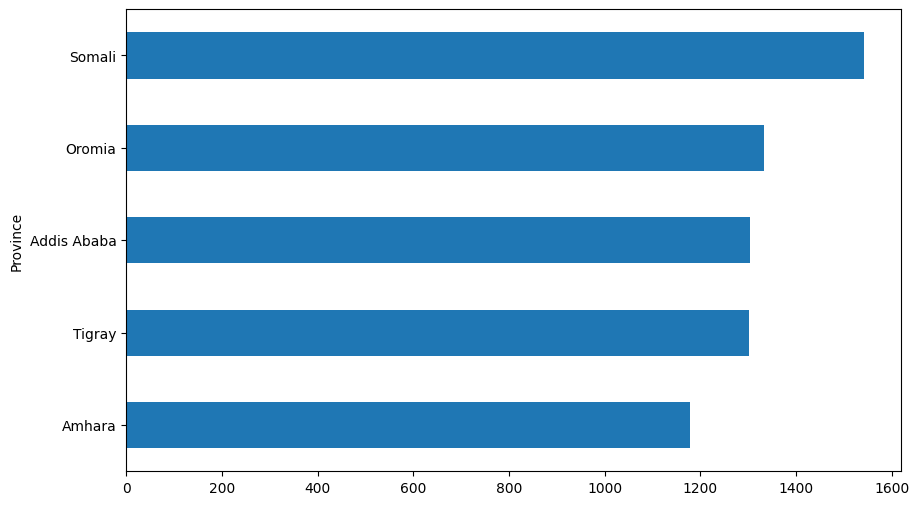

In [17]:
df.groupby("Province")["TotalClaims"].mean() \
    .sort_values() \
    .plot(kind="barh", figsize=(10,6))

<Axes: xlabel='Gender'>

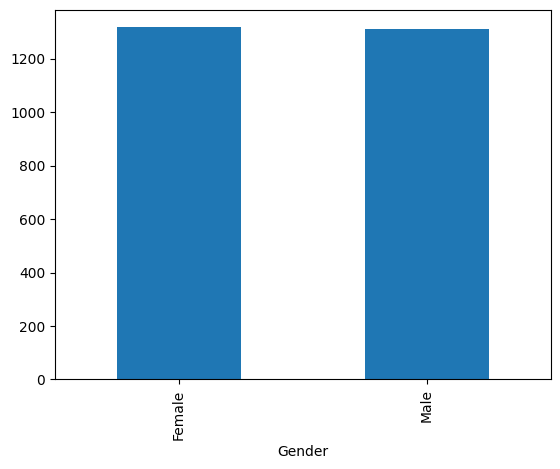

In [18]:
df.groupby("Gender")["TotalClaims"].mean() \
    .plot(kind="bar")

In [19]:
df.groupby("ZipCode")["Margin"].mean() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind="bar")

KeyError: 'PostalCode'